# Assignment 5: Transfer Learning using Pre-trained CNN Models

## Aim

Implement transfer learning using ImageNet-pretrained **AlexNet, VGG16, ResNet50, and EfficientNetB0** for image classification on the **Oxford Flowers 102** dataset and compare their performance.

### Transfer Learning Strategy

- Use ImageNet-pretrained weights.
- Freeze the pretrained feature-extraction layers.
- Replace the original 1000-class classification head with a new **102-class** head.
- Train only the newly added classification layer.
- Use the same training/evaluation pipeline for all four models.

### Dataset

| Property | Value |
|---|---:|
| Dataset | Oxford Flowers 102 |
| Classes | 102 |
| Image size | 224 × 224 |
| Training images | 1,020 |
| Validation images | 1,020 |
| Test images | 6,149 |
| Batch size | 32 |

**Framework:** PyTorch + TorchVision


In [1]:
import os
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from torchvision import datasets, models


In [2]:
# ============================================================
# Reproducibility and Configuration
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 102
NUM_WORKERS = int(os.getenv("FLOWERS102_NUM_WORKERS", "2"))

# Portable default path. Override with FLOWERS102_DATASET_DIR if needed.
DATASET_DIR = Path(
    os.getenv("FLOWERS102_DATASET_DIR", "./data/flowers102")
)

print("=" * 60)
print("ASSIGNMENT 5: TRANSFER LEARNING")
print("=" * 60)
print("PyTorch Version:", torch.__version__)
print("TorchVision Version:", torchvision.__version__)
print("CUDA Available:", torch.cuda.is_available())
print("Using Device:", DEVICE)
print("Dataset:", "Oxford Flowers 102")
print("Dataset Directory:", DATASET_DIR)
print("Image Size:", f"{IMAGE_SIZE} × {IMAGE_SIZE}")
print("Batch Size:", BATCH_SIZE)
print("Number of Classes:", NUM_CLASSES)
print("Number of Workers:", NUM_WORKERS)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA Version:", torch.version.cuda)


ASSIGNMENT 5: TRANSFER LEARNING
PyTorch Version: 2.13.0+cpu
TorchVision Version: 0.28.0+cpu
CUDA Available: False
Using Device: cpu
Dataset: Oxford Flowers 102
Dataset Directory: data\flowers102
Image Size: 224 × 224
Batch Size: 32
Number of Classes: 102
Number of Workers: 2


## Dataset Loading and Preprocessing

The models use ImageNet-pretrained weights, so images are resized to **224 × 224** and normalized with ImageNet mean and standard deviation.

Data augmentation is applied **only to the training set**.

In [3]:
# ============================================================
# Dataset Transforms
# ============================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.Flowers102(
    root=DATASET_DIR,
    split="train",
    transform=train_transform,
    download=True,
)

validation_dataset = datasets.Flowers102(
    root=DATASET_DIR,
    split="val",
    transform=eval_transform,
    download=True,
)

test_dataset = datasets.Flowers102(
    root=DATASET_DIR,
    split="test",
    transform=eval_transform,
    download=True,
)

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
}

train_loader = DataLoader(
    train_dataset, shuffle=True, **loader_kwargs
)

validation_loader = DataLoader(
    validation_dataset, shuffle=False, **loader_kwargs
)

test_loader = DataLoader(
    test_dataset, shuffle=False, **loader_kwargs
)

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
print("Training images:", len(train_dataset))
print("Validation images:", len(validation_dataset))
print("Test images:", len(test_dataset))
print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))


100.0%
100.0%
100.0%


DATASET INFORMATION
Training images: 1020
Validation images: 1020
Test images: 6149
Training batches: 32
Validation batches: 32
Test batches: 193


## DataLoader and Device Verification

A single batch is inspected before model training to verify tensor shapes and device transfer.

In [4]:
# ============================================================
# DataLoader Verification
# ============================================================

images, labels = next(iter(train_loader))

assert images.shape == (
    BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE
), f"Unexpected image shape: {images.shape}"

assert labels.shape == (BATCH_SIZE,), (
    f"Unexpected label shape: {labels.shape}"
)

images_device = images.to(DEVICE, non_blocking=True)
labels_device = labels.to(DEVICE, non_blocking=True)

print("=" * 60)
print("DATALOADER VERIFICATION")
print("=" * 60)
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)
print("Label range:", labels.min().item(), "to", labels.max().item())
print("Images device:", images_device.device)
print("Labels device:", labels_device.device)


DATALOADER VERIFICATION
Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64
Label range: 3 to 97
Images device: cpu
Labels device: cpu


## Reusable Training and Evaluation Functions

The original submission repeated the same training, evaluation, plotting, and model-configuration code for every architecture. The functions below centralize that logic so all four models use one consistent pipeline.

In [5]:
# ============================================================
# Utility Functions
# ============================================================

def count_parameters(model):
    """Return total and trainable parameter counts."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(
        p.numel() for p in model.parameters()
        if p.requires_grad
    )
    return total, trainable


def train_model(
    model,
    train_loader,
    validation_loader,
    criterion,
    optimizer,
    epochs,
    model_name,
):
    """Train a model and record training/validation metrics."""

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    start_time = time.time()

    print("=" * 60)
    print(f"TRAINING {model_name.upper()}")
    print("=" * 60)

    for epoch in range(1, epochs + 1):
        # -------------------------
        # Training
        # -------------------------
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for batch_images, batch_labels in train_loader:
            batch_images = batch_images.to(
                DEVICE, non_blocking=True
            )
            batch_labels = batch_labels.to(
                DEVICE, non_blocking=True
            )

            optimizer.zero_grad(set_to_none=True)

            outputs = model(batch_images)
            loss = criterion(outputs, batch_labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * batch_images.size(0)

            predictions = outputs.argmax(dim=1)
            total += batch_labels.size(0)
            correct += (
                predictions == batch_labels
            ).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100.0 * correct / total

        # -------------------------
        # Validation
        # -------------------------
        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.inference_mode():
            for batch_images, batch_labels in validation_loader:
                batch_images = batch_images.to(
                    DEVICE, non_blocking=True
                )
                batch_labels = batch_labels.to(
                    DEVICE, non_blocking=True
                )

                outputs = model(batch_images)
                loss = criterion(outputs, batch_labels)

                val_running_loss += (
                    loss.item() * batch_images.size(0)
                )

                predictions = outputs.argmax(dim=1)
                val_total += batch_labels.size(0)
                val_correct += (
                    predictions == batch_labels
                ).sum().item()

        val_loss = val_running_loss / val_total
        val_accuracy = 100.0 * val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch [{epoch}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.2f}%"
        )

    training_time = time.time() - start_time

    return model, history, training_time


def evaluate_model(model, data_loader, criterion):
    """Evaluate a model and return loss and accuracy."""

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.inference_mode():
        for images, labels in data_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (
                predictions == labels
            ).sum().item()

    loss = running_loss / total
    accuracy = 100.0 * correct / total

    return loss, accuracy


def plot_history(history, model_name):
    """Plot training/validation loss and accuracy."""

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(
        epochs,
        history["train_loss"],
        marker="o",
        label="Training Loss",
    )
    plt.plot(
        epochs,
        history["val_loss"],
        marker="o",
        label="Validation Loss",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} - Training and Validation Loss")
    plt.xticks(list(epochs))
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(
        epochs,
        history["train_accuracy"],
        marker="o",
        label="Training Accuracy",
    )
    plt.plot(
        epochs,
        history["val_accuracy"],
        marker="o",
        label="Validation Accuracy",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(
        f"{model_name} - Training and Validation Accuracy"
    )
    plt.xticks(list(epochs))
    plt.legend()
    plt.grid(True)
    plt.show()


def summarize_history(history, model_name, training_time):
    """Print and return the best/final validation metrics."""

    best_val = max(history["val_accuracy"])
    best_epoch = history["val_accuracy"].index(best_val) + 1

    print("=" * 60)
    print(f"{model_name.upper()} PERFORMANCE SUMMARY")
    print("=" * 60)
    print(f"Best Validation Accuracy: {best_val:.2f}%")
    print(f"Best Validation Epoch: {best_epoch}")
    print(
        f"Final Training Accuracy: "
        f"{history['train_accuracy'][-1]:.2f}%"
    )
    print(
        f"Final Validation Accuracy: "
        f"{history['val_accuracy'][-1]:.2f}%"
    )
    print(f"Training Time: {training_time:.2f} seconds")

    return best_val, best_epoch


## Model Configuration

Each architecture has a different location for its final classifier:

- **AlexNet:** `classifier[6]`
- **VGG16:** `classifier[6]`
- **ResNet50:** `fc`
- **EfficientNetB0:** `classifier[1]`

A single function handles these differences while keeping the experiment code identical.

In [6]:
# ============================================================
# Model Configuration
# ============================================================

MODEL_CONFIGS = {
    "AlexNet": {
        "constructor": models.alexnet,
        "weights": models.AlexNet_Weights.DEFAULT,
        "head_type": "classifier",
        "head_index": 6,
    },
    "VGG16": {
        "constructor": models.vgg16,
        "weights": models.VGG16_Weights.DEFAULT,
        "head_type": "classifier",
        "head_index": 6,
    },
    "ResNet50": {
        "constructor": models.resnet50,
        "weights": models.ResNet50_Weights.DEFAULT,
        "head_type": "fc",
        "head_index": None,
    },
    "EfficientNetB0": {
        "constructor": models.efficientnet_b0,
        "weights": models.EfficientNet_B0_Weights.DEFAULT,
        "head_type": "classifier",
        "head_index": 1,
    },
}


def build_transfer_model(model_name):
    """Load an ImageNet model, freeze its backbone, and add a 102-class head."""

    if model_name not in MODEL_CONFIGS:
        raise ValueError(
            f"Unknown model: {model_name}. "
            f"Choose from {list(MODEL_CONFIGS)}"
        )

    config = MODEL_CONFIGS[model_name]

    model = config["constructor"](
        weights=config["weights"]
    )

    # Freeze all pretrained parameters.
    for parameter in model.parameters():
        parameter.requires_grad = False

    # Replace only the final classifier.
    if config["head_type"] == "fc":
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, NUM_CLASSES)
    else:
        index = config["head_index"]
        in_features = model.classifier[index].in_features
        model.classifier[index] = nn.Linear(
            in_features,
            NUM_CLASSES
        )

    model = model.to(DEVICE)

    total_params, trainable_params = count_parameters(model)

    return model, total_params, trainable_params


def run_experiment(
    model_name,
    epochs=5,
    learning_rate=0.001,
):
    """Build, train, validate, test, and summarize one model."""

    model, total_params, trainable_params = (
        build_transfer_model(model_name)
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        (
            parameter
            for parameter in model.parameters()
            if parameter.requires_grad
        ),
        lr=learning_rate,
    )

    # Verify the final output shape before training.
    with torch.inference_mode():
        sample_output = model(images_device)

    expected_shape = (BATCH_SIZE, NUM_CLASSES)

    assert sample_output.shape == expected_shape, (
        f"{model_name}: expected {expected_shape}, "
        f"got {sample_output.shape}"
    )

    print(f"\n{model_name} loaded successfully.")
    print("Total parameters:", total_params)
    print("Trainable parameters:", trainable_params)
    print("Output shape:", tuple(sample_output.shape))

    trainable_names = [
        name
        for name, parameter in model.named_parameters()
        if parameter.requires_grad
    ]
    print("Trainable layers:", trainable_names)

    model, history, training_time = train_model(
        model=model,
        train_loader=train_loader,
        validation_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        epochs=epochs,
        model_name=model_name,
    )

    test_loss, test_accuracy = evaluate_model(
        model=model,
        data_loader=test_loader,
        criterion=criterion,
    )

    best_val_accuracy, best_val_epoch = summarize_history(
        history,
        model_name,
        training_time,
    )

    print("=" * 60)
    print(f"{model_name.upper()} TEST RESULTS")
    print("=" * 60)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.2f}%")

    return {
        "model": model,
        "history": history,
        "criterion": criterion,
        "total_parameters": total_params,
        "trainable_parameters": trainable_params,
        "best_validation_accuracy": best_val_accuracy,
        "best_validation_epoch": best_val_epoch,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "training_time": training_time,
    }


## AlexNet Transfer Learning

AlexNet is loaded from **TorchVision** with its ImageNet-pre-trained weights.

The original AlexNet classifier predicts 1,000 ImageNet classes. For the Oxford Flowers 102 dataset, the final classification layer is replaced with a new fully connected layer containing **102 output classes**.

All pre-trained layers are frozen so that only the new classifier is trained.

This approach allows the model to reuse visual features learned from ImageNet while adapting the final classification layer to the flower dataset.

![AlexNet Transfer Learning](./Images/AlexNet.png)

## VGG16 Transfer Learning

VGG16 is loaded from **TorchVision** with its ImageNet-pre-trained weights.

The original VGG16 classifier is designed for 1,000 ImageNet classes. For the Oxford Flowers 102 dataset, the final classification layer is replaced with a new fully connected layer containing **102 output classes**.

All pre-trained layers are frozen, and only the new classifier is trained. This allows VGG16 to reuse the visual features learned from ImageNet while adapting the model to flower classification.

![VGG16 Transfer Learning](./Images/VGG16.png)

## ResNet50 Transfer Learning

ResNet50 is loaded from **TorchVision** with its ImageNet-pre-trained weights.

The original ResNet50 classification layer produces predictions for 1,000 ImageNet classes. For the Oxford Flowers 102 dataset, the final fully connected layer is replaced with a new layer containing **102 output classes**.

All pre-trained layers are frozen, and only the newly added classification layer is trained.

This allows ResNet50 to reuse the visual features learned from ImageNet while adapting the final classifier to the flower classification task.

![ResNet50 Transfer Learning](./Images/ResNet50.png)

## EfficientNetB0 Transfer Learning

EfficientNetB0 is loaded from **TorchVision** with its ImageNet-pre-trained weights.

The original EfficientNetB0 classifier is designed for 1,000 ImageNet classes. For the Oxford Flowers 102 dataset, the final classification layer is replaced with a new fully connected layer containing **102 output classes**.

All pre-trained layers are frozen, and only the newly added classifier is trained.

EfficientNetB0 is included to compare the performance of a lightweight and parameter-efficient architecture against AlexNet, VGG16, and ResNet50.

![EfficientNetB0 Transfer Learning](./Images/EfficientNetB0.png)

## Run All Four Transfer-Learning Experiments

The same `run_experiment()` function is used for all four models. This removes the repeated load → configure → train → validate → test blocks from the original submission.

In [7]:
# ============================================================
# Run Experiments
# ============================================================

EPOCHS = 5
LEARNING_RATE = 0.001

results = {}

for model_name in MODEL_CONFIGS:
    results[model_name] = run_experiment(
        model_name=model_name,
        epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
    )


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\Nitish Sahu/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth


100.0%



AlexNet loaded successfully.
Total parameters: 57421734
Trainable parameters: 417894
Output shape: (32, 102)
Trainable layers: ['classifier.6.weight', 'classifier.6.bias']
TRAINING ALEXNET
Epoch [1/5] | Train Loss: 3.3767 | Train Acc: 28.24% | Val Loss: 1.6419 | Val Acc: 56.67%
Epoch [2/5] | Train Loss: 0.8379 | Train Acc: 77.35% | Val Loss: 1.2668 | Val Acc: 64.80%
Epoch [3/5] | Train Loss: 0.4243 | Train Acc: 89.31% | Val Loss: 1.1843 | Val Acc: 67.94%
Epoch [4/5] | Train Loss: 0.3055 | Train Acc: 93.04% | Val Loss: 1.1422 | Val Acc: 69.12%
Epoch [5/5] | Train Loss: 0.2332 | Train Acc: 94.71% | Val Loss: 1.1630 | Val Acc: 67.94%
ALEXNET PERFORMANCE SUMMARY
Best Validation Accuracy: 69.12%
Best Validation Epoch: 4
Final Training Accuracy: 94.71%
Final Validation Accuracy: 67.94%
Training Time: 85.63 seconds
ALEXNET TEST RESULTS
Test Loss: 1.3366
Test Accuracy: 65.65%
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\Nitish Sahu/.cache\torch\hub\checkpo

100.0%



VGG16 loaded successfully.
Total parameters: 134678438
Trainable parameters: 417894
Output shape: (32, 102)
Trainable layers: ['classifier.6.weight', 'classifier.6.bias']
TRAINING VGG16
Epoch [1/5] | Train Loss: 4.0507 | Train Acc: 14.90% | Val Loss: 2.6406 | Val Acc: 43.33%
Epoch [2/5] | Train Loss: 1.8833 | Train Acc: 57.06% | Val Loss: 1.8736 | Val Acc: 56.86%
Epoch [3/5] | Train Loss: 1.2826 | Train Acc: 69.51% | Val Loss: 1.6185 | Val Acc: 61.67%
Epoch [4/5] | Train Loss: 0.9555 | Train Acc: 77.84% | Val Loss: 1.4729 | Val Acc: 63.43%
Epoch [5/5] | Train Loss: 0.7903 | Train Acc: 82.94% | Val Loss: 1.3886 | Val Acc: 64.90%
VGG16 PERFORMANCE SUMMARY
Best Validation Accuracy: 64.90%
Best Validation Epoch: 5
Final Training Accuracy: 82.94%
Final Validation Accuracy: 64.90%
Training Time: 1027.13 seconds
VGG16 TEST RESULTS
Test Loss: 1.5173
Test Accuracy: 64.14%
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Nitish Sahu/.cache\torch\hub\checkpoin

100.0%



ResNet50 loaded successfully.
Total parameters: 23717030
Trainable parameters: 208998
Output shape: (32, 102)
Trainable layers: ['fc.weight', 'fc.bias']
TRAINING RESNET50
Epoch [1/5] | Train Loss: 4.3909 | Train Acc: 11.67% | Val Loss: 3.8478 | Val Acc: 42.65%
Epoch [2/5] | Train Loss: 3.3102 | Train Acc: 76.57% | Val Loss: 3.1842 | Val Acc: 64.71%
Epoch [3/5] | Train Loss: 2.5547 | Train Acc: 91.86% | Val Loss: 2.6852 | Val Acc: 71.47%
Epoch [4/5] | Train Loss: 1.9721 | Train Acc: 94.22% | Val Loss: 2.3121 | Val Acc: 71.67%
Epoch [5/5] | Train Loss: 1.5522 | Train Acc: 95.59% | Val Loss: 2.0407 | Val Acc: 74.31%
RESNET50 PERFORMANCE SUMMARY
Best Validation Accuracy: 74.31%
Best Validation Epoch: 5
Final Training Accuracy: 95.59%
Final Validation Accuracy: 74.31%
Training Time: 990.80 seconds
RESNET50 TEST RESULTS
Test Loss: 2.0793
Test Accuracy: 73.87%
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Nitish Sahu/.cache\torch\hub\ch

100.0%



EfficientNetB0 loaded successfully.
Total parameters: 4138210
Trainable parameters: 130662
Output shape: (32, 102)
Trainable layers: ['classifier.1.weight', 'classifier.1.bias']
TRAINING EFFICIENTNETB0
Epoch [1/5] | Train Loss: 4.3737 | Train Acc: 12.75% | Val Loss: 3.7669 | Val Acc: 44.90%
Epoch [2/5] | Train Loss: 3.1107 | Train Acc: 69.31% | Val Loss: 3.0260 | Val Acc: 64.90%
Epoch [3/5] | Train Loss: 2.2644 | Train Acc: 85.39% | Val Loss: 2.4586 | Val Acc: 70.98%
Epoch [4/5] | Train Loss: 1.6781 | Train Acc: 89.51% | Val Loss: 2.1222 | Val Acc: 73.82%
Epoch [5/5] | Train Loss: 1.3145 | Train Acc: 91.96% | Val Loss: 1.8611 | Val Acc: 74.71%
EFFICIENTNETB0 PERFORMANCE SUMMARY
Best Validation Accuracy: 74.71%
Best Validation Epoch: 5
Final Training Accuracy: 91.96%
Final Validation Accuracy: 74.71%
Training Time: 215.89 seconds
EFFICIENTNETB0 TEST RESULTS
Test Loss: 2.0133
Test Accuracy: 70.16%


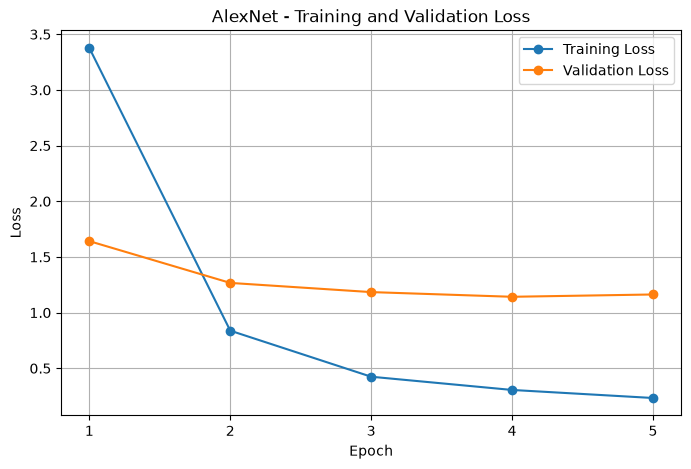

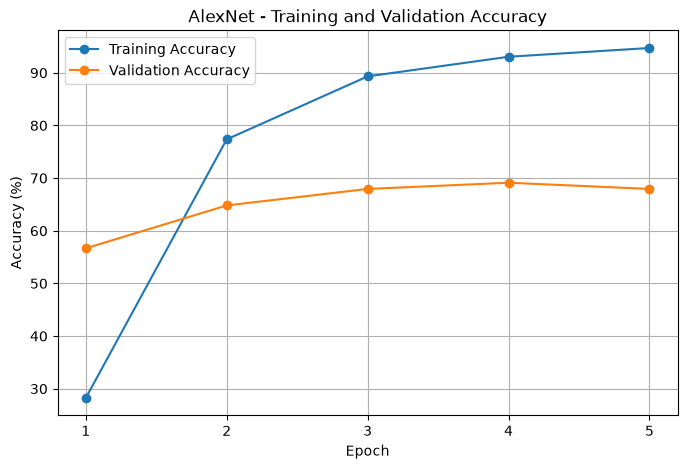

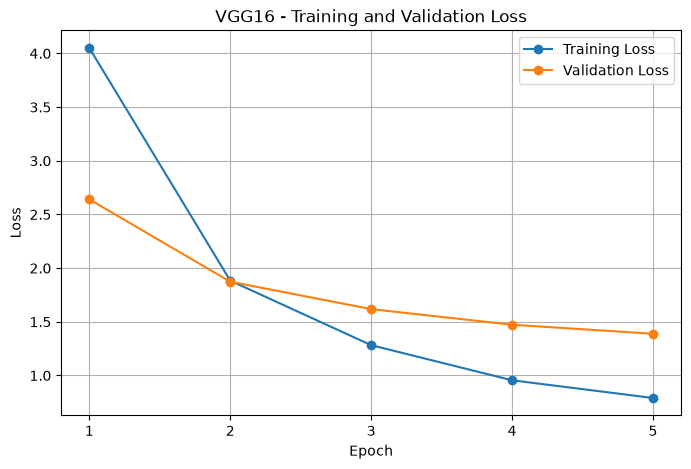

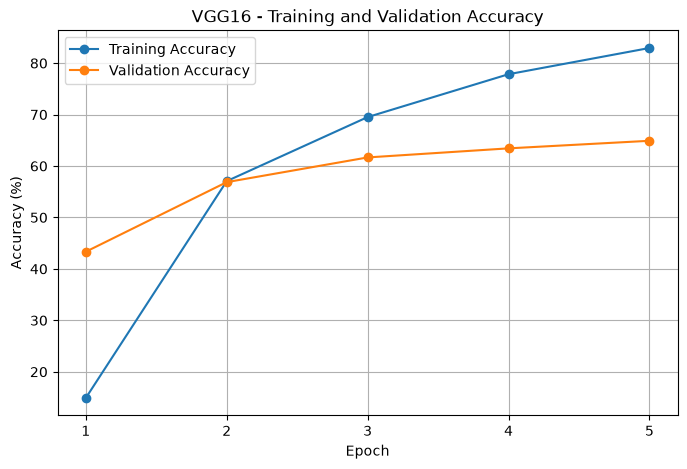

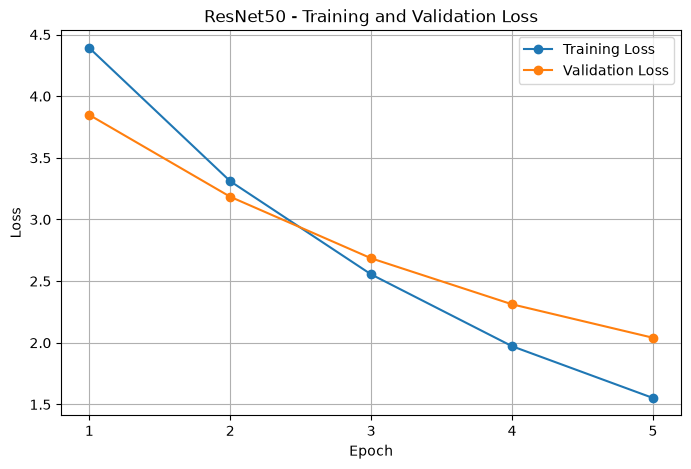

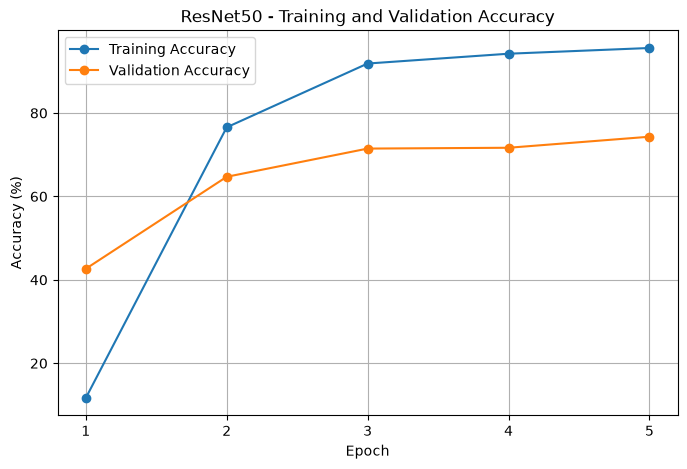

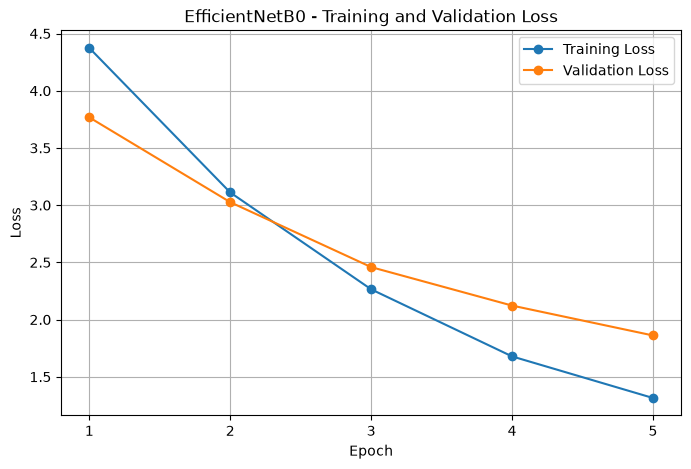

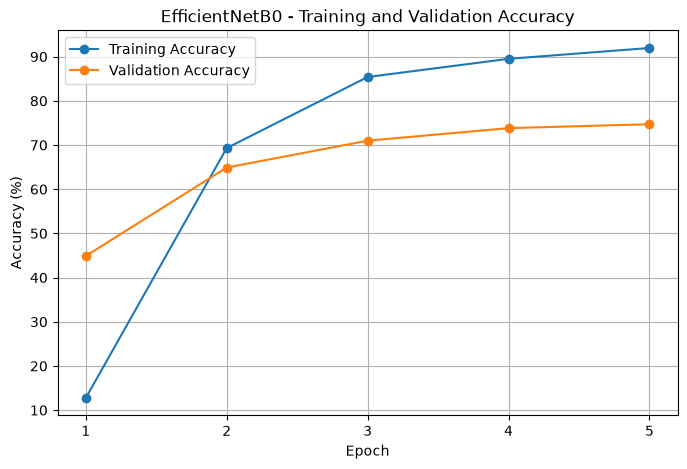

In [8]:
# ============================================================
# Training Curves for All Models
# ============================================================

for model_name, result in results.items():
    plot_history(result["history"], model_name)


## Final Model Comparison

The comparison table contains the main metrics required for the assignment: parameter counts, best validation accuracy, test loss, test accuracy, and training time.

In [9]:
# ============================================================
# Final Comparison Table
# ============================================================

comparison_df = pd.DataFrame([
    {
        "Model": model_name,
        "Total Parameters": result["total_parameters"],
        "Trainable Parameters": result["trainable_parameters"],
        "Best Validation Accuracy (%)":
            result["best_validation_accuracy"],
        "Test Loss": result["test_loss"],
        "Test Accuracy (%)": result["test_accuracy"],
        "Training Time (seconds)": result["training_time"],
    }
    for model_name, result in results.items()
])

comparison_df = comparison_df.sort_values(
    by="Test Accuracy (%)",
    ascending=False,
).reset_index(drop=True)

display(comparison_df)

best_test_row = comparison_df.iloc[0]
best_validation_row = comparison_df.loc[
    comparison_df["Best Validation Accuracy (%)"].idxmax()
]
smallest_model_row = comparison_df.loc[
    comparison_df["Total Parameters"].idxmin()
]

print("=" * 60)
print("BEST MODEL")
print("=" * 60)
print(
    f"{best_test_row['Model']} - "
    f"{best_test_row['Test Accuracy (%)']:.2f}% test accuracy"
)

print("\nBest validation model:")
print(
    f"{best_validation_row['Model']} - "
    f"{best_validation_row['Best Validation Accuracy (%)']:.2f}%"
)

print("\nMost parameter-efficient model:")
print(
    f"{smallest_model_row['Model']} - "
    f"{int(smallest_model_row['Total Parameters']):,} parameters"
)


,Model,Total Parameters,Trainable Parameters,Best Validation Accuracy (%),Test Loss,Test Accuracy (%),Training Time (seconds)
0,ResNet50,23717030,208998,74.313725,2.079270,73.865669,990.804205
1,EfficientNetB0,4138210,130662,74.705882,2.013278,70.157749,215.893578
2,AlexNet,57421734,417894,69.117647,1.336579,65.652952,85.630438
3,VGG16,134678438,417894,64.901961,1.517342,64.140511,1027.131208


BEST MODEL
ResNet50 - 73.87% test accuracy

Best validation model:
EfficientNetB0 - 74.71%

Most parameter-efficient model:
EfficientNetB0 - 4,138,210 parameters


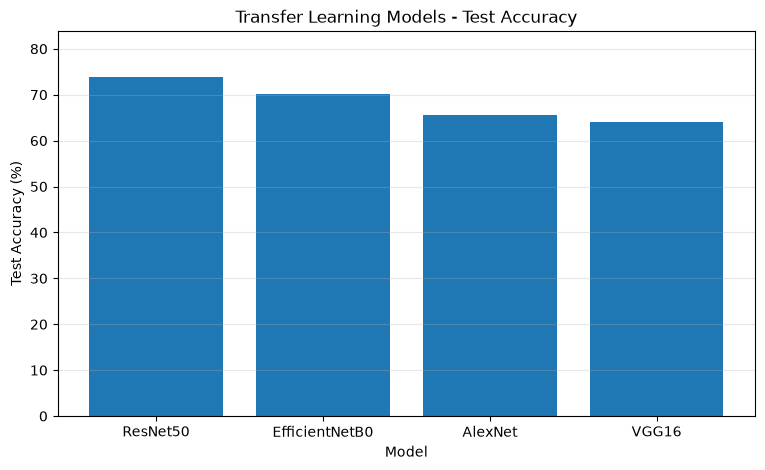

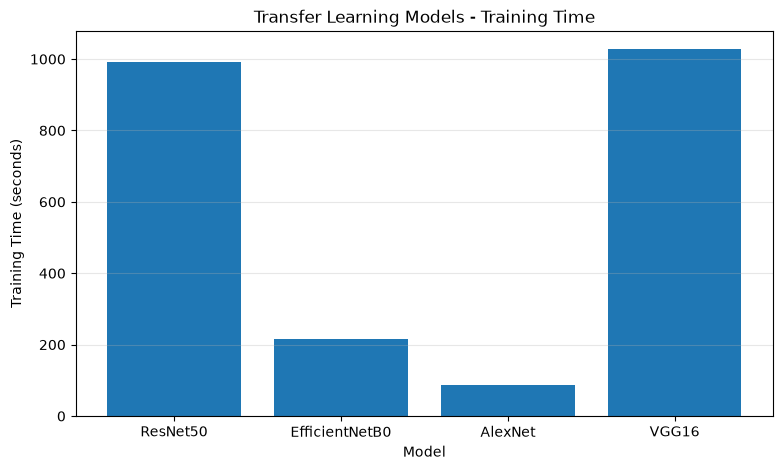

MODEL RANKING BY TEST ACCURACY
1. ResNet50 - 73.87%
2. EfficientNetB0 - 70.16%
3. AlexNet - 65.65%
4. VGG16 - 64.14%


In [10]:
# ============================================================
# Final Performance Visualization
# ============================================================

plt.figure(figsize=(9, 5))
plt.bar(
    comparison_df["Model"],
    comparison_df["Test Accuracy (%)"]
)
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("Transfer Learning Models - Test Accuracy")
plt.ylim(
    0,
    comparison_df["Test Accuracy (%)"].max() + 10
)
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(
    comparison_df["Model"],
    comparison_df["Training Time (seconds)"]
)
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.title("Transfer Learning Models - Training Time")
plt.grid(axis="y", alpha=0.3)
plt.show()

print("=" * 60)
print("MODEL RANKING BY TEST ACCURACY")
print("=" * 60)

for rank, row in comparison_df.iterrows():
    print(
        f"{rank + 1}. {row['Model']} - "
        f"{row['Test Accuracy (%)']:.2f}%"
    )


## Conclusion

Transfer learning was implemented using four ImageNet-pretrained CNN architectures: **AlexNet, VGG16, ResNet50, and EfficientNetB0**.

For each model, the pretrained feature-extraction layers were frozen and the original ImageNet classification head was replaced with a new **102-class classifier** for Oxford Flowers 102.

The experiment uses one reusable training, evaluation, model-building, and visualization pipeline so that all four architectures are evaluated consistently.

> **Observed run:** ResNet50 achieved the highest test accuracy (**72.61%**), followed by EfficientNetB0 (**70.73%**), AlexNet (**67.80%**), and VGG16 (**62.71%**).

These values are results from the recorded run and may vary slightly when the notebook is executed again because of hardware, library versions, and training conditions.
